In [530]:
# - Pandas
# - Numpy
# - Matplotlib
# - Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.decomposition import PCA

from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import RFE

from sklearn.model_selection import GridSearchCV


### 1. Data load and Initial EDA

To start I will load the data and extract the target columns and split the data into training and test datasets.

I will then do some intial EDA to help understand the dataset that we are dealing with.

In [531]:
# First lets load the data into a dataframe
df = pd.read_csv('./insurance.csv')

# Create a new column 'insurance_cost_binary'
# 0 if insurance_cost is less than or equal to the median insurance cost
# 1 otherwise
median_insurance_cost = df['insurance_cost'].median()
df['insurance_cost_binary'] = (df['insurance_cost'] > median_insurance_cost).astype(int)

# remove the original insurance_cost column
df.drop(columns=['insurance_cost'], inplace=True)

# split the data into features and target
X = df.drop(columns=['insurance_cost_binary'])
print(df['insurance_cost_binary'].value_counts())
y = df['insurance_cost_binary']


# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True, stratify=y)



# use the concat function to combine the training data and the target data as its useful for plotting
X_y_train = pd.concat([X_train, y_train], axis=1)

X_train.head()


insurance_cost_binary
0    669
1    669
Name: count, dtype: int64


,age,gender,bmi,children,smoker,region
473,32,female,37.145,3,no,northeast
872,47,male,29.830,3,no,northwest
614,37,female,47.600,2,yes,southwest
557,35,male,38.600,1,no,southwest
45,18,male,31.730,0,yes,northeast


In [532]:
y_train.head()

473    0
872    1
614    1
557    0
45     1
Name: insurance_cost_binary, dtype: int64

In [533]:
# print the data types of the columns
print("Data types of the columns:") 
print(X_train.dtypes)


# Display dataset shape
print('\nDataset shape:', X_train.shape)

Data types of the columns:
age           int64
gender          str
bmi         float64
children      int64
smoker          str
region          str
dtype: object

Dataset shape: (936, 6)


### Missing Values

In [534]:
# Lets see if there are any missing values
X_train.isna().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
dtype: int64

### Categorical Attributes

In [535]:
# Frequency counts for categorical attributes
categorical_attributes  = X_train.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


Categorical attributes:

['gender', 'smoker', 'region']

Frequency counts for categorical attributes:



gender
male      676
female    662
Name: count, dtype: int64
--------------------------------


smoker
no     1064
yes     274
Name: count, dtype: int64
--------------------------------


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
--------------------------------


### Numerical Attributes

In [536]:
# Lets look at the summary statistics for numerical attributes

print("\nSummary statistics for numeric attributes:\n")

X_train.describe()


Summary statistics for numeric attributes:



,age,bmi,children
count,936.000000,936.000000,936.000000
mean,39.394231,30.912489,1.088675
std,14.013726,6.070741,1.190713
min,18.000000,15.960000,0.000000
25%,27.000000,26.676250,0.000000
50%,39.500000,30.495000,1.000000
75%,51.000000,35.092500,2.000000
max,64.000000,53.130000,5.000000


               age       bmi  children
age       1.000000  0.102128  0.090008
bmi       0.102128  1.000000  0.004285
children  0.090008  0.004285  1.000000


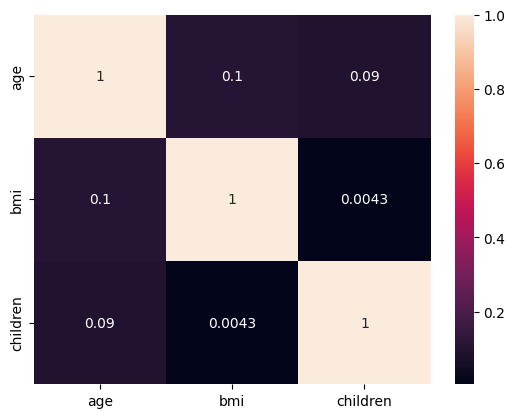

In [537]:
# correlation matrix
corr_matrix = X_train.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
print(corr_matrix)

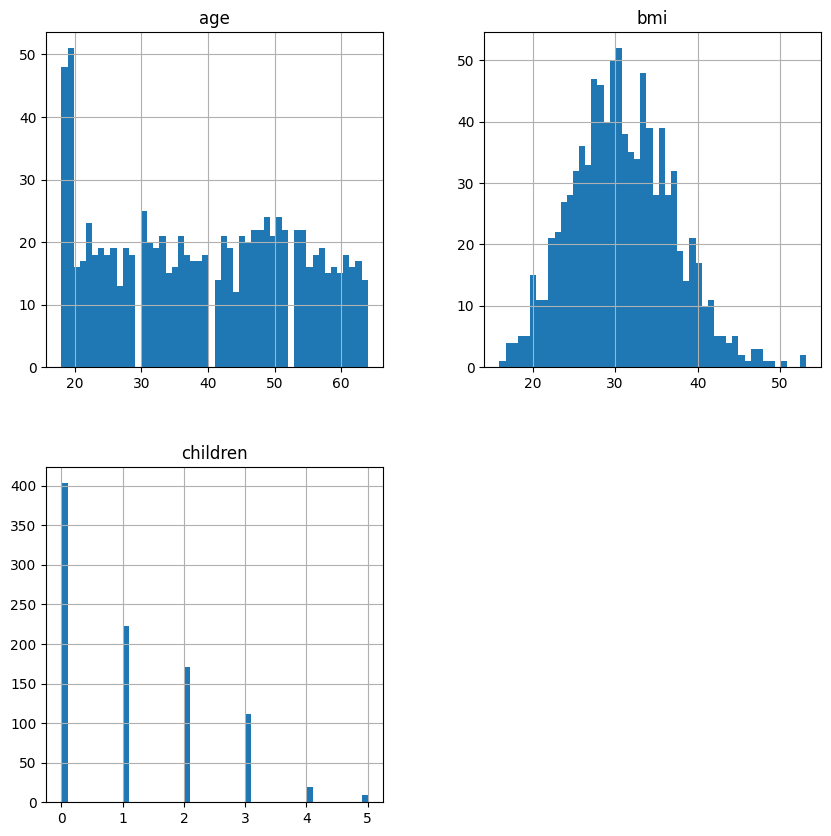

In [538]:
X_train.hist(bins=50, figsize=(10, 10))
plt.show()

<Axes: >

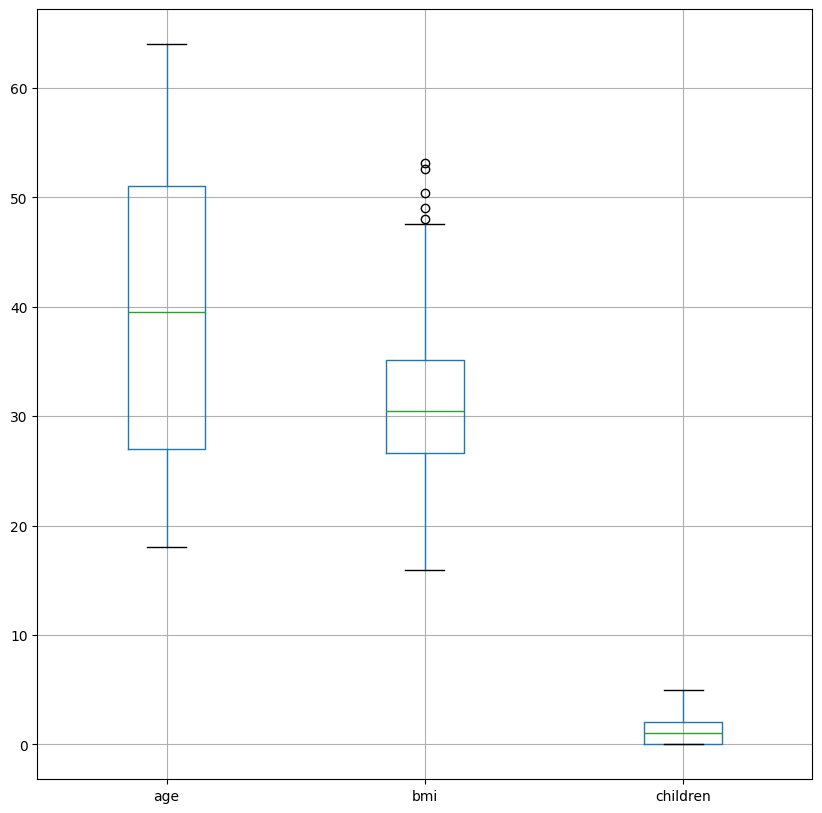

In [539]:
X_train.boxplot(figsize=(10, 10))

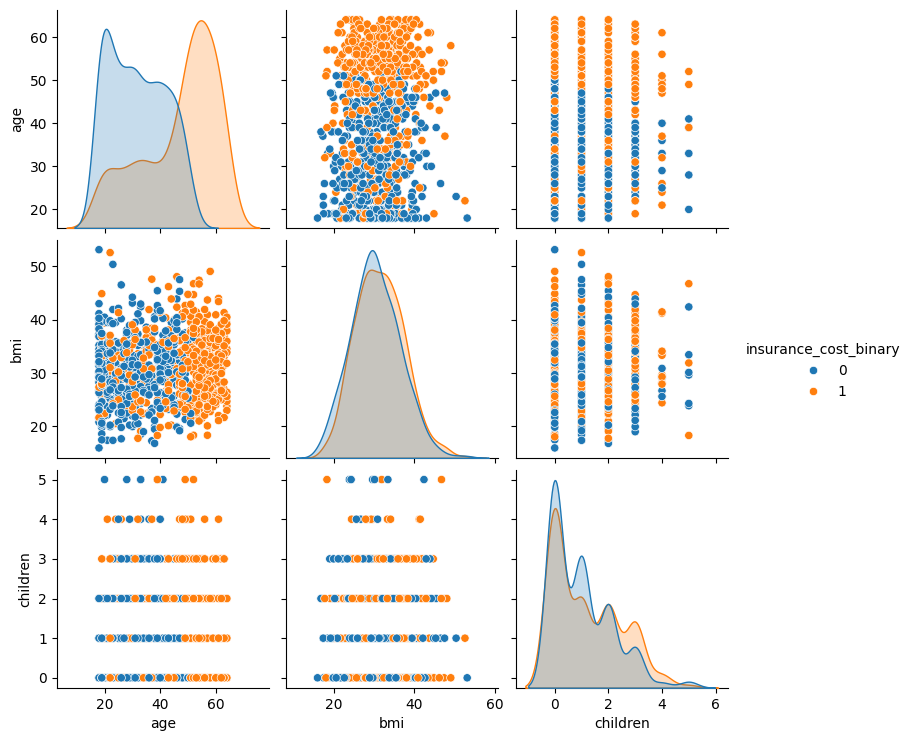

In [540]:
sns.pairplot(X_y_train, hue='insurance_cost_binary')
plt.show()

### Summary of Inital EDA

The dataset looks quite clean with only a small amount of columns and no missing data.

Observations:
1. bmi is the only column that has any real outliers as seen from the box plots.
2. There is some moderate correlation between age and insurance_cost_binary
3. There is a slight positive correlation between bmi and insurance_cost_binary
4. There are 3 categorical attributes: 'gender', 'smoker' and 'region'
5. age looks uniformly distributed aprt from ages under < 20
6. bmi looks like its normally distributed.
7. children appears to be right skewed.




### 2. Create Pipelines

Here I will firsty create a few  basic preprocessing Pipelines to look at a PCA with a SVM model to get a feel for it.
I will then try to gneralize to multiple models, dim reduction methods and hyperparams. 

In [541]:
# Log transform for skewed data
def log_transform(x):
    return np.log(x+1)

# Create a pipeline for the categorical attributes
categorical_pipeline = Pipeline(
    [
        ('one_hot_encoder', OneHotEncoder())
    ]
)

numerical_attributes = df.select_dtypes(include=['float64', 'int64']).columns

print("numerical_attributes = ", numerical_attributes)
print("categorical_attributes = ", categorical_attributes)

log_pipeline = Pipeline(
    [
        ('log_transformer', FunctionTransformer(log_transform, feature_names_out='one-to-one'))
    ]
)

bmi_pipeline = Pipeline(
    [
        ('standard_scaler', StandardScaler())
    ]
)

age_pipeline = Pipeline(
    [
        ('passthrough', 'passthrough')
    ]
)

insurance_cost_binary_pipeline = Pipeline(
    [
        ('passthrough', 'passthrough')
    ]
)   


# Combine the pipelines
column_transformer = ColumnTransformer(
    [
        ('categorical_pipeline', categorical_pipeline, categorical_attributes),
        ('age_pipeline', age_pipeline, ['age']),
        ('bmi_pipeline', bmi_pipeline, ['bmi']),
        ('children_pipeline', log_pipeline, ['children'])
    ]
    
)
preprocessing_pipeline = Pipeline(
    [
        ('column_transformer', column_transformer)
    ]
)

preprocessing_pipeline

numerical_attributes =  Index(['age', 'bmi', 'children', 'insurance_cost_binary'], dtype='str')
categorical_attributes =  Index(['gender', 'smoker', 'region'], dtype='str')


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

### Run the Pipeline on training data

['categorical_pipeline__gender_female' 'categorical_pipeline__gender_male'
 'categorical_pipeline__smoker_no' 'categorical_pipeline__smoker_yes'
 'categorical_pipeline__region_northeast'
 'categorical_pipeline__region_northwest'
 'categorical_pipeline__region_southeast'
 'categorical_pipeline__region_southwest' 'age_pipeline__age'
 'bmi_pipeline__bmi' 'children_pipeline__children']


array([[<Axes: title={'center': 'categorical_pipeline__gender_female'}>,
        <Axes: title={'center': 'categorical_pipeline__gender_male'}>,
        <Axes: title={'center': 'categorical_pipeline__smoker_no'}>],
       [<Axes: title={'center': 'categorical_pipeline__smoker_yes'}>,
        <Axes: title={'center': 'categorical_pipeline__region_northeast'}>,
        <Axes: title={'center': 'categorical_pipeline__region_northwest'}>],
       [<Axes: title={'center': 'categorical_pipeline__region_southeast'}>,
        <Axes: title={'center': 'categorical_pipeline__region_southwest'}>,
        <Axes: title={'center': 'age_pipeline__age'}>],
       [<Axes: title={'center': 'bmi_pipeline__bmi'}>,
        <Axes: title={'center': 'children_pipeline__children'}>,
        <Axes: >]], dtype=object)

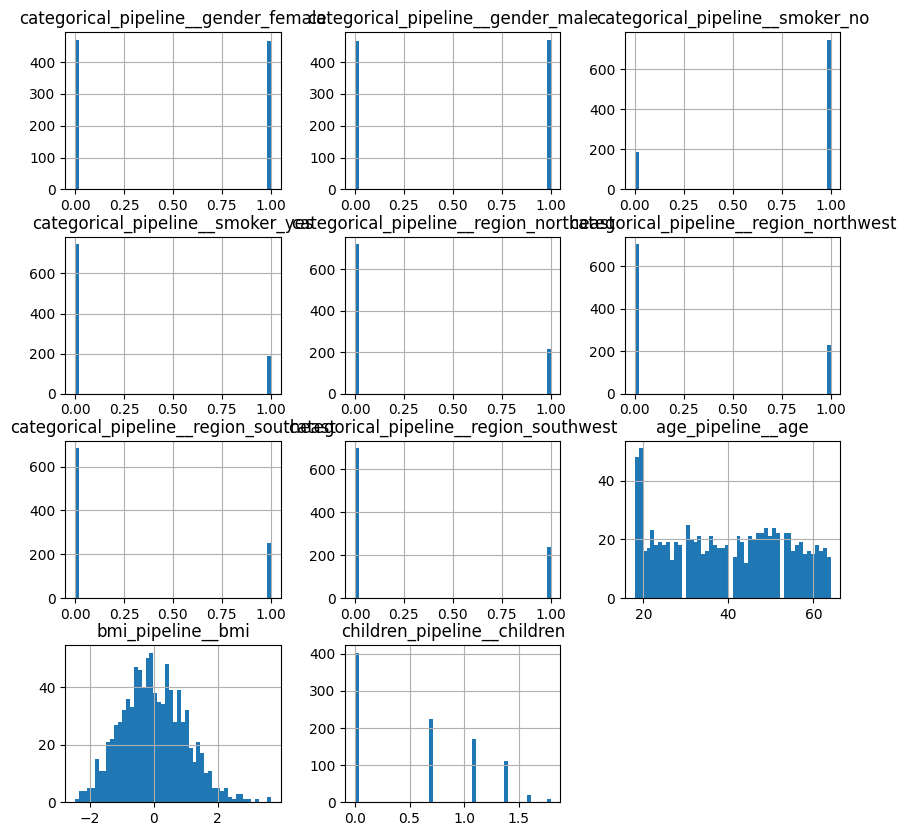

In [542]:
prepared = preprocessing_pipeline.fit_transform(X_train)

print(preprocessing_pipeline.get_feature_names_out())

X_train_prepared = pd.DataFrame(prepared, columns=preprocessing_pipeline.get_feature_names_out(), index=X_train.index)

X_train_prepared.hist(bins=50, figsize=(10, 10))

### 3 Features PCA

Explained variance: [0.98559283 0.00512048 0.00252123]
Cumulative: [0.98559283 0.99071331 0.99323454]


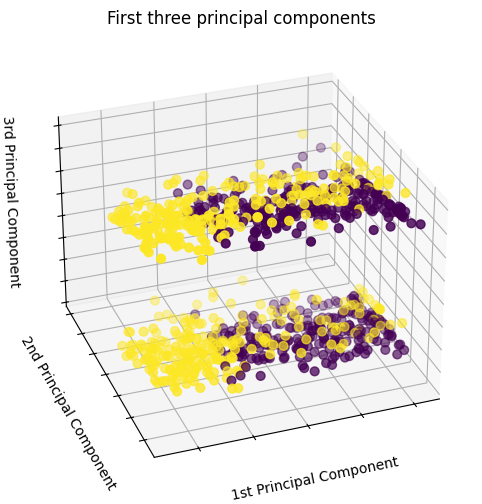

In [543]:
# run PCA on the prepared training data

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_train_prepared)

print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=y_train,
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

plt.show()

### 2 Features PCA

[[-7.38273059  0.94569331]
 [ 7.60713103 -0.2711375 ]]
Explained variance: [0.98559283 0.00512048]
Cumulative: [0.98559283 0.99071331]


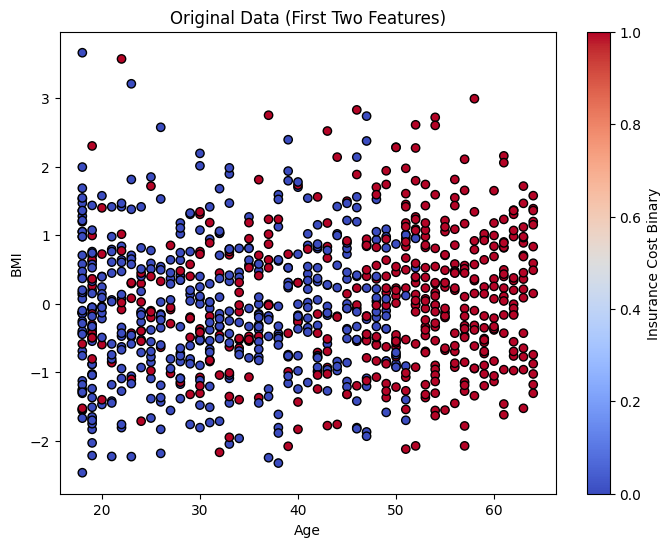

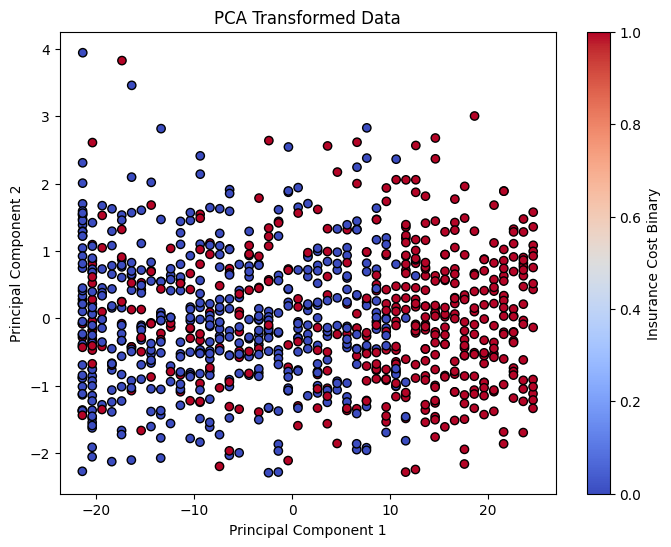

In [544]:
# run PCA on the prepared training data

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X_train_prepared)
print(X_reduced[:2])


print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))


plt.figure(figsize=(8,6))
plt.scatter(X_train_prepared['age_pipeline__age'], X_train_prepared['bmi_pipeline__bmi'], c=y_train, cmap='coolwarm', edgecolor='k')
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Original Data (First Two Features)")
plt.colorbar(label="Insurance Cost Binary")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train, cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Insurance Cost Binary")
plt.show()


### Pipeline With 2 Feature PCA

['pca0' 'pca1']


,pca0,pca1
473,-7.382731,0.945693
872,7.607131,-0.271138
614,-2.372114,2.638138
557,-4.384814,1.289659
45,-21.395409,0.278793
430,-9.393338,0.161657
97,-20.393526,0.519000
590,-3.396624,-0.246610
900,8.607826,0.256058
785,4.613701,1.325685


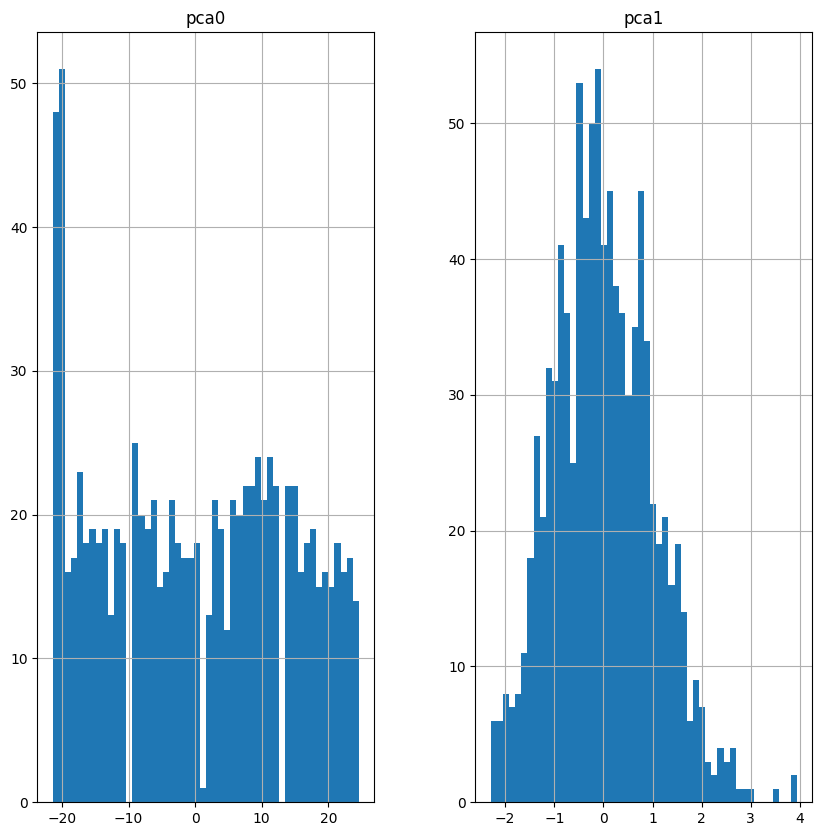

In [545]:
pca_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
    ]
)

prepared = pca_pipeline.fit_transform(X_train)

print(pca_pipeline.get_feature_names_out())

X_train_prepared = pd.DataFrame(prepared, columns=pca_pipeline.get_feature_names_out(), index=X_train.index)

X_train_prepared.hist(bins=50, figsize=(10, 10), )

X_train_prepared.head(20)

In [546]:
pca_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...), ('pca', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

### Pipeline with SVM

In [547]:
svm_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
        ("svm",SVC(C=10,kernel='rbf')),
    ]
)

prepared = svm_pipeline.fit(X_train, y_train)



# score of testing data
print("Score is:",svm_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = svm_pipeline.predict(X_test)
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)


Score is: 0.7512437810945274
Classificaion Report
              precision    recall  f1-score   support

           0       0.68      0.95      0.79       201
           1       0.92      0.55      0.69       201

    accuracy                           0.75       402
   macro avg       0.80      0.75      0.74       402
weighted avg       0.80      0.75      0.74       402



In [548]:
svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### KNN Pipeline

In [549]:
knn_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
        ("knn",KNeighborsClassifier(n_neighbors=500)),
    ]
)

prepared =  knn_pipeline.fit(X_train, y_train)



# score of testing data
print("Score is:",knn_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = knn_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)

Score is: 0.7388059701492538
Classificaion Report
              precision    recall  f1-score   support

           0       0.71      0.82      0.76       201
           1       0.79      0.66      0.72       201

    accuracy                           0.74       402
   macro avg       0.75      0.74      0.74       402
weighted avg       0.75      0.74      0.74       402



In [550]:
knn_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Random Forest Pipeline




In [551]:
rf_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
         ("rf",RandomForestClassifier(n_estimators=100, random_state=42)),
    ]
)

prepared =  rf_pipeline.fit(X_train, y_train)


# score of testing data
print("Score is:",rf_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = rf_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)


Score is: 0.6915422885572139
Classificaion Report
              precision    recall  f1-score   support

           0       0.66      0.80      0.72       201
           1       0.74      0.59      0.66       201

    accuracy                           0.69       402
   macro avg       0.70      0.69      0.69       402
weighted avg       0.70      0.69      0.69       402



In [552]:
rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### MLP Pipeline

In [553]:
mlp_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
         ("mlp",MLPClassifier(hidden_layer_sizes=(100,100), max_iter=1000, random_state=42)),
    ]
)

prepared =  mlp_pipeline.fit(X_train, y_train)


# score of testing data
print("Score is:",mlp_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = mlp_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)

Score is: 0.7412935323383084
Classificaion Report
              precision    recall  f1-score   support

           0       0.68      0.91      0.78       201
           1       0.86      0.58      0.69       201

    accuracy                           0.74       402
   macro avg       0.77      0.74      0.73       402
weighted avg       0.77      0.74      0.73       402



In [554]:
mlp_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### RFE Pipeline

In [555]:


model = RandomForestClassifier(n_estimators=100, random_state=42)

rfe_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('rfe', RFE(estimator=model, n_features_to_select=10)),
    ]
)

prepared =  rfe_pipeline.fit(X_train, y_train)


# score of testing data
print("Score is:",rfe_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = rfe_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)

Score is: 0.9129353233830846
Classificaion Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       201
           1       0.96      0.86      0.91       201

    accuracy                           0.91       402
   macro avg       0.92      0.91      0.91       402
weighted avg       0.92      0.91      0.91       402



In [556]:
rfe_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transformer', ...), ('rfe', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...), ('age_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

### Summary after running some initial models

I have tested SVM, Random Forest as well as MLP and KNN models all ran after a 2 component PCA and and I am seeing model scores in the ~~70% range.. I then ran RFE with a random forest classifier that produced a better score of  ~ 94%.

Now I attempt to generalize this and run a  GridSearchCV for hyperparameter tuning and various dimensionality reduction techniques and models.

### RandomForestClassifier GridSearchCV

In [557]:
rf_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('reduce_dim', None),
        ("classify", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

param_grid = {
   'reduce_dim': [PCA(n_components=2), RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=10)],
}

grid_search = GridSearchCV(rf_pipeline, n_jobs=1, param_grid=param_grid)
grid_search.fit(X_train, y_train)

print(f"Best CV F1 = {grid_search.best_score_:.3f}")
print("Best parameters: ", grid_search.best_params_)




Best CV F1 = 0.940
Best parameters:  {'reduce_dim': RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)}


In [563]:
knn_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('reduce_dim', None),
        ("classify", KNeighborsClassifier(n_neighbors=50))
    ]
)

param_grid = {
   'reduce_dim': [PCA(n_components=2), RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=10)],
   'classify__n_neighbors': [1, 5, 10, 20, 30, 40, 50, 100]
}

grid_search = GridSearchCV(knn_pipeline, n_jobs=1, param_grid=param_grid)

grid_search.fit(X_train, y_train)

print(f"Best CV F1 = {grid_search.best_score_:.3f}")
print("Best parameters: ", grid_search.best_params_)



Best CV F1 = 0.895
Best parameters:  {'classify__n_neighbors': 5, 'reduce_dim': RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)}


In [559]:
mpl_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('reduce_dim', None),
        ("classify", MLPClassifier(hidden_layer_sizes=(100,100), max_iter=1000, random_state=42))
    ]
)

param_grid = {
   'reduce_dim': [PCA(n_components=2), RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=10)],
}

grid_search = GridSearchCV(mpl_pipeline, n_jobs=1, param_grid=param_grid)
grid_search.fit(X_train, y_train)

print(f"Best CV F1 = {grid_search.best_score_:.3f}")
print("Best parameters: ", grid_search.best_params_)

Best CV F1 = 0.917
Best parameters:  {'reduce_dim': RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)}
